Environment Setup

In [39]:
import pandas as pd
import numpy as np
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

print("[SYSTEM] Environment ready. Apple Inc. Global Sales libraries imported.")

[SYSTEM] Environment ready. Apple Inc. Global Sales libraries imported.


In [40]:
import sys
!{sys.executable} -m pip install networkx

In [41]:
import sys
!{sys.executable} -m pip install plotly

In [42]:
import sys
!{sys.executable} -m pip install plotly

Initializing the Data Lake

In [50]:
# 1.1 INITIALIZING THE APPLE DATA LAKE
os.makedirs('apple_data_lake', exist_ok=True)
np.random.seed(42)
num_records = 5000

# Attributes for Apple Inc. Global Retail
products = ["iPhone 15 Pro", "MacBook Air M3", "iPad Pro", "Apple Watch Ultra", "AirPods Max", "Vision Pro"]
hubs = ["NYC-FifthAve", "London-RegentSt", "Tokyo-Ginza", "Paris-Opera", "Sydney-GeorgeSt"]
store_details = {
    "NYC-FifthAve": "767 Fifth Ave, New York", 
    "London-RegentSt": "235 Regent St, London", 
    "Tokyo-Ginza": "3-5-12 Ginza, Chuo-ku", 
    "Paris-Opera": "12 Boulevard des Capucines", 
    "Sydney-GeorgeSt": "367 George St, Sydney"
}

# 1.2 SOURCE A: Messy JSON (Apple Online Store API)
# Contains nested structures, string-based noise in prices, and location errors.
json_lake = []
for i in range(num_records):
    price_val = np.random.uniform(129, 3499)
    if np.random.rand() < 0.05:
        # Intentional Type Mix-up (Schema-on-Read challenge)
        price_val = "REFUNDED" if np.random.rand() > 0.5 else "AUTH_FAILED"
        
    json_lake.append({
        "order_id": f"APPLE_WEB_{i:05d}",
        "metadata": {
            "timestamp": (pd.to_datetime('2024-01-01') + pd.Timedelta(days=np.random.randint(0, 180))).strftime('%Y-%m-%d'),
            "region": np.random.choice(hubs + ["UNKNOWN_LOC", "NULL_ZONE"])
        },
        "cart": [{"model": np.random.choice(products), "quantity": np.random.randint(1, 3), "unit_price": price_val}]
    })

with open('apple_data_lake/online_orders.json', 'w') as f:
    json.dump(json_lake, f)

# 1.3 SOURCE B: Messy CSV (Physical Apple Store POS)
# Contains missing quantities (NaNs) and negative price outliers.
csv_rows = []
for i in range(num_records):
    qty = np.random.randint(1, 10)
    if np.random.rand() < 0.04: 
        qty = None  # Missing values to be handled during ETL
        
    csv_rows.append({
        "TXN_ID": f"RETAIL_{i:05d}",
        "DATE": (pd.to_datetime('2024-07-01') + pd.Timedelta(days=np.random.randint(0, 180))).strftime('%Y-%m-%d'),
        "STORE_HUB": np.random.choice(hubs),
        "SKU_NAME": np.random.choice(products),
        "UNITS_SOLD": qty,
        "PRICE_TAG": np.random.uniform(-500, 4000) # Negative outliers representing clerical errors
    })

pd.DataFrame(csv_rows).to_csv('apple_data_lake/retail_pos_logs.csv', index=False)

print("[SYSTEM] Apple Global Retail Data Lake initialized with messy JSON and CSV files.")

[SYSTEM] Apple Global Retail Data Lake initialized with messy JSON and CSV files.


Exploratory Data Analysis (EDA)

In [24]:
# 2.1 Load and Flatten JSON (Apple Online Store)
with open('apple_data_lake/online_orders.json', 'r') as f:
    raw_json = json.load(f)

# Flattening the nested structure: cart -> metadata
df_web = pd.json_normalize(
    raw_json, 
    record_path=['cart'], 
    meta=[['metadata', 'timestamp'], ['metadata', 'region'], 'order_id']
)

# 2.2 Load CSV (Retail Store POS)
df_retail = pd.read_csv('apple_data_lake/retail_pos_logs.csv')

print("--- Source A (Online JSON) EDA ---")
print(df_web.info())
print("\nUnique values in unit_price (Notice the strings):")
print(df_web['unit_price'].unique()[:5])

print("\n--- Source B (Retail CSV) EDA ---")
print(df_retail.info())
print("\nCheck for Negative Prices (Errors):")
print(df_retail[df_retail['PRICE_TAG'] < 0].head())

--- Source A (Online JSON) EDA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   model               5000 non-null   object
 1   quantity            5000 non-null   int64 
 2   unit_price          5000 non-null   object
 3   metadata.timestamp  5000 non-null   object
 4   metadata.region     5000 non-null   object
 5   order_id            5000 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
None

Unique values in unit_price (Notice the strings):
[1391.2002005156116 1631.4563771166022 'REFUNDED' 3472.752954811403
 206.72037238957108]

--- Source B (Retail CSV) EDA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TXN_ID      5000 non-null   object 
 1   DATE     

Data Integration, Cleaning & Warehousing (The ETL Pipeline)

In [32]:
# --- 1. INTEGRATION (Standardization) ---
# Mapping the Apple Online (Web) and Apple Retail (CSV) columns to a single standard
df_web.columns = ['Product', 'Quantity', 'Price', 'Date', 'Store', 'TXN_ID']
df_retail.columns = ['TXN_ID', 'Date', 'Store', 'Product', 'Quantity', 'Price']

# Combine both sources into a single unified Dataframe
integrated_df = pd.concat([df_web, df_retail], ignore_index=True)

# --- 2. THE DATA QUALITY GATE (Cleaning & Transformation) ---
before = len(integrated_df)

# Fix Type Mix-ups: Coerce errors (like "REFUNDED") to NaN
integrated_df['Quantity'] = pd.to_numeric(integrated_df['Quantity'], errors='coerce')
integrated_df['Price'] = pd.to_numeric(integrated_df['Price'], errors='coerce')

# Remove duplicates
integrated_df = integrated_df.drop_duplicates()

# Filter valid rows: Remove rows with null values in essential columns
integrated_df = integrated_df.dropna(subset=['Store', 'Quantity', 'Price'])

# Filter out Apple-specific location errors and negative price outliers
integrated_df = integrated_df[~integrated_df['Store'].isin(["UNKNOWN_LOC", "NULL_ZONE"])]
integrated_df = integrated_df[integrated_df['Price'] > 0]

# Feature Engineering
integrated_df['Date'] = pd.to_datetime(integrated_df['Date'])
integrated_df['Revenue'] = integrated_df['Quantity'] * integrated_df['Price']

# Adding Quarter for OLAP Cube analysis
integrated_df['Quarter'] = 'Q' + integrated_df['Date'].dt.quarter.astype(str)

after = len(integrated_df)
print(f"[ETL] Cleaned {before - after} noisy records. Trusted rows: {after}")

# Display first 10 rows of the trusted Data Warehouse data
print("\n--- Apple Inc. Data Warehouse (Cleaned Fact Table) ---")
print(integrated_df.head(10))

[ETL] Cleaned 2379 noisy records. Trusted rows: 7621

--- Apple Inc. Data Warehouse (Cleaned Fact Table) ---
              Product  Quantity        Price       Date            Store  \
0         AirPods Max       1.0  1391.200201 2024-04-16  Sydney-GeorgeSt   
1   Apple Watch Ultra       2.0  1631.456377 2024-03-28  Sydney-GeorgeSt   
4   Apple Watch Ultra       2.0   206.720372 2024-06-18      Paris-Opera   
5   Apple Watch Ultra       2.0   913.439417 2024-02-20      Paris-Opera   
6       iPhone 15 Pro       1.0  1701.990950 2024-05-14  Sydney-GeorgeSt   
7      MacBook Air M3       1.0   173.702919 2024-01-14  London-RegentSt   
11     MacBook Air M3       2.0   751.959515 2024-02-13  London-RegentSt   
14      iPhone 15 Pro       1.0  1331.258711 2024-05-03  Sydney-GeorgeSt   
15      iPhone 15 Pro       2.0  2832.403825 2024-03-11     NYC-FifthAve   
17      iPhone 15 Pro       2.0  2171.085115 2024-02-10      Paris-Opera   

             TXN_ID      Revenue Quarter  
0   APPLE_W

In [45]:
# --- TASK: BIG PICTURE VIEW ---
mean_revenue = integrated_df['Revenue'].mean()
max_revenue = integrated_df['Revenue'].max()

print(f"Mean Revenue per transaction: ${mean_revenue:,.2f}")
print(f"Max Revenue in a single sale: ${max_revenue:,.2f}")

Mean Revenue per transaction: $6,783.81
Max Revenue in a single sale: $35,976.13


OLAP Operations (Multidimensional Analysis)

Slice, Dice, Roll up & Roll Down

In [46]:
# 1. SLICE: Selection on one dimension (Q1 only)
slice_q1 = integrated_df[integrated_df['Quarter'] == 'Q1']
print(f"Slice (Q1) Total: ${slice_q1['Revenue'].sum():,.2f}")

# 2. DICE: Sub-cube selection (iPhone + London + Q1)
dice_data = integrated_df[
    (integrated_df['Product'] == 'iPhone 15 Pro') & 
    (integrated_df['Store'] == 'London-RegentSt') & 
    (integrated_df['Quarter'] == 'Q1')
]
print(f"Dice (iPhone/London/Q1): ${dice_data['Revenue'].sum():,.2f}")

# 3. ROLL-UP: Moving from Date to Yearly totals
rollup_yr = integrated_df.groupby(integrated_df['Date'].dt.year)['Revenue'].sum().reset_index()
print("\n--- Roll-up: Yearly Totals ---")
print(rollup_yr)

# 4. DRILL-DOWN: Moving from Store to specific Store Address
address_map = {
    "NYC-FifthAve": "767 Fifth Ave", "London-RegentSt": "235 Regent St", 
    "Tokyo-Ginza": "3-5-12 Ginza", "Paris-Opera": "12 Blvd Capucines", "Sydney-GeorgeSt": "367 George St"
}
integrated_df['Store_Address'] = integrated_df['Store'].map(address_map)
drill_down = integrated_df.groupby(['Store', 'Store_Address'])['Revenue'].sum().reset_index()
print("\n--- Drill-down: Store Level Detail ---")
print(drill_down)

Slice (Q1) Total: $4,728,349.64
Dice (iPhone/London/Q1): $151,191.78

--- Roll-up: Yearly Totals ---
   Date       Revenue
0  2024  5.169938e+07

--- Drill-down: Store Level Detail ---
             Store      Store_Address       Revenue
0  London-RegentSt      235 Regent St  1.034738e+07
1     NYC-FifthAve      767 Fifth Ave  9.807769e+06
2      Paris-Opera  12 Blvd Capucines  9.963499e+06
3  Sydney-GeorgeSt      367 George St  1.101090e+07
4      Tokyo-Ginza       3-5-12 Ginza  1.056984e+07


Cross-Tabulation and Heatmap

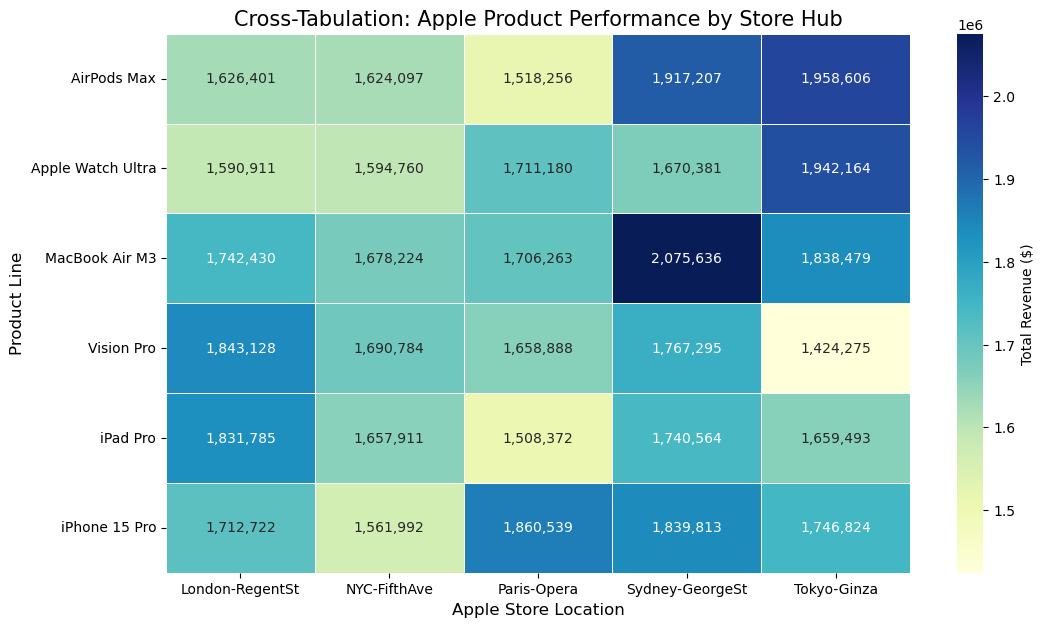

In [47]:
# 1. CROSS-TABULATION (Pivoting Product vs Store)
# We aggregate the sum of Revenue to see the performance of each SKU per region
apple_pivot = integrated_df.pivot_table(
    index='Product', 
    columns='Store', 
    values='Revenue', 
    aggfunc='sum'
)

# 2. HEATMAP VISUALIZATION
plt.figure(figsize=(12, 7))
sns.heatmap(
    apple_pivot, 
    annot=True,          # Show the revenue numbers in the cells
    fmt=",.0f",          # Format numbers with commas and no decimals
    cmap="YlGnBu",       # Yellow-Green-Blue color palette
    linewidths=.5,       # Add a small gap between cells
    cbar_kws={'label': 'Total Revenue ($)'}
)

plt.title("Cross-Tabulation: Apple Product Performance by Store Hub", fontsize=15)
plt.xlabel("Apple Store Location", fontsize=12)
plt.ylabel("Product Line", fontsize=12)

# Save the plot for the report screenshots
plt.savefig('apple_heatmap.png', bbox_inches='tight')
plt.show()

The Curse of Dimensionality and PCA

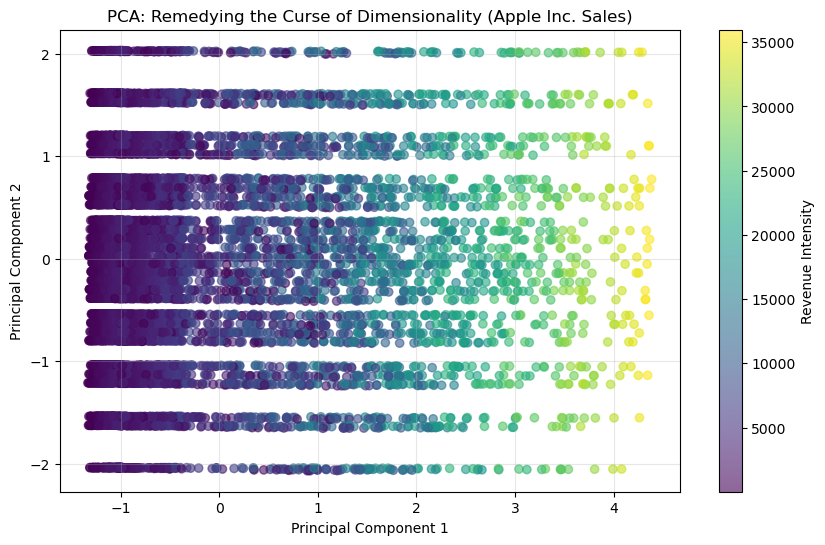

Total Variance Preserved by 2 Components: 68.58%


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Data Preparation: Encoding categorical dimensions
integrated_df['Prod_Code'] = integrated_df['Product'].astype('category').cat.codes
integrated_df['Store_Code'] = integrated_df['Store'].astype('category').cat.codes
X = integrated_df[['Revenue', 'Quantity', 'Prod_Code', 'Store_Code']]

# 2. Scaling and PCA Application
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Visualization: Compressed 2D Representation
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=integrated_df['Revenue'], cmap='viridis', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Remedying the Curse of Dimensionality (Apple Inc. Sales)')
plt.colorbar(label='Revenue Intensity')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total Variance Preserved by 2 Components: {sum(pca.explained_variance_ratio_)*100:.2f}%")